# Palace CPW Simulation — Wave Ports

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a CPW (coplanar waveguide) structure with **wave ports**.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Define GSG electrode

In [6]:
%load_ext autoreload
%autoreload 2

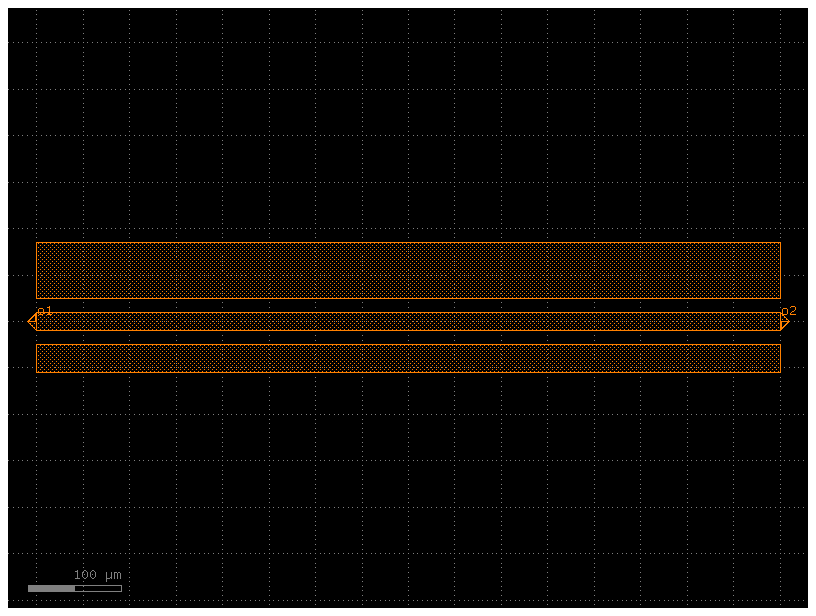

In [ ]:
from pathlib import Path

import gdsfactory as gf
import gdsfactory.component as gf_component
import gdsfactory.config as gf_config
from ihp import LAYER, PDK

# Work around environments where /tmp/gdsfactory is not writable.
# Both modules keep their own reference to GDSDIR_TEMP, so update both.
gf_tmp = Path.home() / ".gdsfactory" / "tmp"
gf_tmp.mkdir(parents=True, exist_ok=True)
gf_config.GDSDIR_TEMP = gf_tmp
gf_component.GDSDIR_TEMP = gf_tmp

PDK.activate()


@gf.cell
def gsg_electrode(
    length: float = 800,
    s_width: float = 20,
    g_width: float = 40,
    g_width_top: float | None = None,
    g_width_bottom: float | None = None,
    gap_width_top: float = 15,
    gap_width_bottom: float = 15,
    layer=LAYER.TopMetal2drawing,
) -> gf.Component:
    """
    Create a GSG (Ground-Signal-Ground) electrode.

    Supports different gap widths on the top and bottom sides
    of the signal electrode for asymmetric CPW modelling.
    Also supports different ground electrode widths.

    Args:
        length: horizontal length of the electrodes
        s_width: width of the signal (center) electrode
        g_width: width of the ground electrodes (default, used if g_width_top/bottom are None)
        g_width_top: width of the top ground electrode (overrides g_width)
        g_width_bottom: width of the bottom ground electrode (overrides g_width)
        gap_width_top: gap between signal and top ground electrode
        gap_width_bottom: gap between signal and bottom ground electrode
        layer: layer for the metal
    """
    g_width_top = g_width if g_width_top is None else g_width_top
    g_width_bottom = g_width if g_width_bottom is None else g_width_bottom

    c = gf.Component()

    r1 = c << gf.c.rectangle((length, g_width_top), centered=True, layer=layer)
    r1.move((0, (g_width_top + s_width) / 2 + gap_width_top))

    _r2 = c << gf.c.rectangle((length, s_width), centered=True, layer=layer)

    r3 = c << gf.c.rectangle((length, g_width_bottom), centered=True, layer=layer)
    r3.move((0, -(g_width_bottom + s_width) / 2 - gap_width_bottom))

    c.add_port(
        name="o1",
        center=(-length / 2, 0),
        width=s_width,
        orientation=180,
        port_type="electrical",
        layer=layer,
    )

    c.add_port(
        name="o2",
        center=(length / 2, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=layer,
    )

    return c


c = gsg_electrode(
    length=800,
    s_width=20,
    g_width=40,
    g_width_top=40,
    g_width_bottom=40,
    gap_width_top=15,
    gap_width_bottom=15,
)
cc = c.copy()
cc.draw_ports()
cc

### Run simulation

In [2]:
import importlib

import gsim.common.cross_section as cross_section
from gsim.common.stack import get_stack
from gsim.palace import BoundaryModeSim

palace_executable = "/home/martin/Desktop/palace/build/bin/palace"

# Reload in case cross_section.py changed during this session.
importlib.reload(cross_section)

# Build a BoundaryMode simulation on an x-normal cross section.
mode_sim = BoundaryModeSim()
mode_sim.set_output_dir("./palace-sim-cpw-waveport-2d")

stack = get_stack()  # auto-detects active PDK
mode_sim.set_stack(stack)
mode_sim.set_airbox(margin_x=50.0, margin_y=50, z_above=100.0, z_below=100.0)
mode_sim.set_geometry(c)

freq = 30e9

mode_sim.set_cross_section("x=0")
mode_sim.set_boundary_mode(freq=freq, num_modes=2, save=2)

# Inspect the geometric cross section before meshing.
section = cross_section.extract_plane_section(c.copy(), stack, axis="x", value=0.0)
print(f"Cross section x=0 intersects {len(section)} layer regions")
print("Stack dielectric regions:", stack.dielectrics)

mode_sim.mesh(
    preset="default",
    refined_mesh_size=2.0,
    max_mesh_size=40.0,
    fmax=150e9,
    margin_x=0.0,
    margin_y=50.0,
)

# Show the native 2D domains used by the BoundaryMode solver.
domain_groups = list(mode_sim._last_mesh_result.groups["volumes"].keys())
print("2D domain groups:", domain_groups)

Cross section x=0 intersects 3 layer regions
Stack dielectric regions: [{'name': 'oxide', 'zmin': -2.0, 'zmax': 14.030000000000001, 'material': 'sio2'}, {'name': 'passive', 'zmin': 14.030000000000001, 'zmax': 15.930000000000001, 'material': 'sin'}]
2D domain groups: ['sin', 'sio2', 'air']


### Run simulation

In [3]:
mode_sim.write_config()
mode_results = mode_sim.run_local(
    palace_executable=palace_executable,
    use_apptainer=False,
    num_processes=16,
    verbose=True,
)

Running Palace simulation in palace-sim-cpw-waveport-2d directly
Command: /home/martin/Desktop/palace/build/bin/palace -np 16 config.json
Processes: 16
>> /usr/bin/mpirun -n 16 /home/martin/Desktop/palace/build/bin/palace-x86_64.bin config.json
_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/
--> Warning!
Output folder is not empty; program will overwrite content! (output/palace)
Git changeset ID: v0.16.1-51-g4f2e2d976
Running with 16 MPI processes, 1 OpenMP thread
Device configuration: omp,cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked
--> Warning!
One or more external boundary attributes has no associated boundary condition!
"PMC"/"ZeroCharge" condition is assumed!
Boundary attribute list: 5
Added 332 boundary elements for material interfaces to the mesh
Characteristic length and time scales:
 Lc = 3.400e-0

Frequency: 30.0 GHz

Mode     Re(k_n) [1/m]        Im(k_n) [1/m]        v_p [m/s]          v_p / c0     n_eff       
-----------------------------------------------------------------------------------------------
1        1.097903e+03         -1.722359e+01        1.716869e+08       0.572686     1.746158    
2        9.158000e+02         -7.875117e+00        2.058261e+08       0.686562     1.456533    


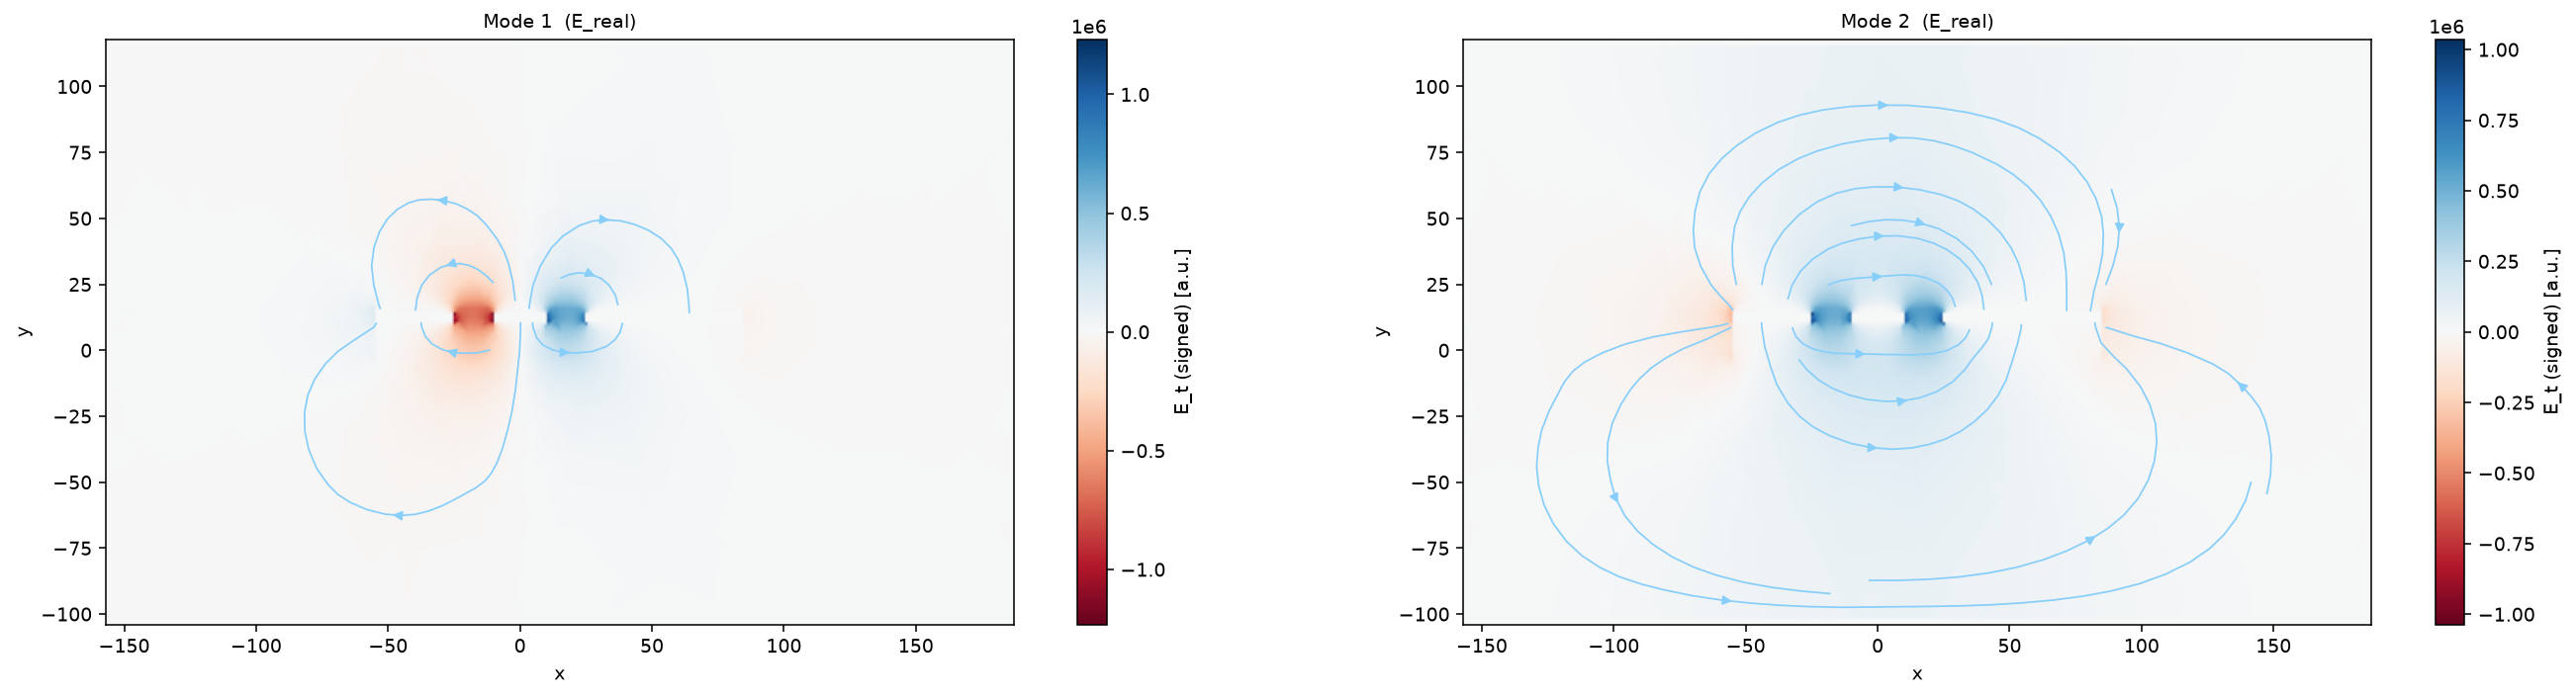

In [8]:
import importlib

import gsim.palace.field_viz as field_viz
import gsim.palace.results as palace_results
from gsim.palace import plot_fields_2d

# Reload to ensure notebook uses latest implementation from disk.
importlib.reload(field_viz)
importlib.reload(palace_results)

# If this kernel still holds an older PalaceTextResults object (e.g. from a
# previous run_local that didn't set freq_hz), patch in the correct frequency.
if not hasattr(mode_results, "freq_hz") or mode_results.freq_hz is None:
    mode_results.freq_hz = freq

# Pretty-print mode summaries with phase velocity (Im/Re k_n, v_p, n_eff).
mode_results.print()

# Centralized plotting utility from gsim source with tuned defaults.
# For boundary mode, cycles=[1, 2] selects the ParaView cycles corresponding.
# Use chip_bounds to crop the airbox — here (y_min, y_max, z_min, z_max)
# covers the electrode stack without the surrounding air region.
# chip_ymax = 90  # g_width_top/2 + max_gap + s_width/2 + margin
# chip_ymin = -60
# chip_zmax = 30.0  # top of metal + small margin
# chip_zmin = -10.0  # bottom of stack + small margin

fig, axes, stream_inputs_list = plot_fields_2d(
    "./palace-sim-cpw-waveport-2d",
    field="E_real",
    scalar="real",
    cycles=[1, 2],
    # chip_bounds=(chip_ymin, chip_ymax, chip_zmin, chip_zmax),
    show=True,
)

### Phase analysis of the electric field in the two gaps

For a quasi-TEM CPW mode, the electric field in the two gaps (signal-to-ground) should be $180^\circ$ out of phase. We probe the complex $\vec{E}$ field at points inside each gap and compare their phases.

In [5]:
import numpy as np
import pyvista as pv

from gsim.palace.results import load_fields

# Geometry parameters matching the gsg_electrode() call above.
_s_width = 20
_gap_width_top = 15
_gap_width_bottom = 15

# Probe points: middle of each gap, at the metal layer height (z ~ 0).
#   top gap center:    y = +s_width/2 + gap_width_top/2
#   bottom gap center: y = -s_width/2 - gap_width_bottom/2
gap_top_y = _s_width / 2 + _gap_width_top / 2
gap_bot_y = -(_s_width / 2 + _gap_width_bottom / 2)
probe_pts = np.array([[0.0, gap_top_y, 0.0], [0.0, gap_bot_y, 0.0]])

print("Probe points:")
print(f"  top gap center:    y = {gap_top_y:+.2f}")
print(f"  bottom gap center: y = {gap_bot_y:+.2f}\n")

for mode_idx in [1, 2]:
    ds = load_fields("./palace-sim-cpw-waveport-2d", cycle=mode_idx)

    # Build a pyvista PolyData probe set and sample the dataset.
    probe = pv.PolyData(probe_pts)
    sampled = probe.sample(ds, snap_to_closest_point=True)

    # Complex E = E_real + 1j * E_imag (3-component vectors).
    er = np.asarray(sampled.point_data["E_real"]).reshape(-1, 3)
    ei = np.asarray(sampled.point_data["E_imag"]).reshape(-1, 3)
    ec = er + 1j * ei

    # Use the vector sum's phase as a robust scalar.
    phase_top = np.angle(np.sum(ec[0]))
    phase_bot = np.angle(np.sum(ec[1]))
    delta = np.degrees(phase_top - phase_bot)
    delta = (delta + 180.0) % 360.0 - 180.0  # wrap to (-180, 180]

    print(f"Mode {mode_idx}:")
    print(
        f"  top gap    |E|={np.abs(ec[0]).mean():.4e},  phase={np.degrees(phase_top):+7.1f} deg"
    )
    print(
        f"  bottom gap |E|={np.abs(ec[1]).mean():.4e},  phase={np.degrees(phase_bot):+7.1f} deg"
    )
    print(f"  phase difference = {delta:+7.1f} deg  (expect ~180 for quasi-TEM)\n")

Probe points:
  top gap center:    y = +17.50
  bottom gap center: y = -17.50



ValueError: cannot reshape array of size 4 into shape (3)